In [20]:
from pathlib import Path
REPO_ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "absorption_paper_source_data").is_dir())
from CifFile import CifBlock, CifFile
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# INPUT FILES
# ---------------------------------------------------------
base = Path(str(REPO_ROOT / "absorption_paper_source_data/refinement_results/cspbbr_abs"))


asu_file       = base / "asu.csv"
adp_file       = base / "atp.csv"
thickness_file = base / "thickness.csv"
residuals_file = base / "residuals.csv"

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
asu_df   = pd.read_csv(asu_file)
adp_df   = pd.read_csv(adp_file)
thick_df = pd.read_csv(thickness_file)
res_df   = pd.read_csv(residuals_file)

# ---------------------------------------------------------
# BUILD CIF BLOCK
# ---------------------------------------------------------
block = CifBlock()

# =========================================================
# 1) ASU POSITIONS + GRADIENTS
# =========================================================
block["_atom_site_asu_atom_id"] = asu_df["atom_id"].astype(str).tolist()
block["_atom_site_asu_type"]    = asu_df["element"].astype(str).tolist()
block["_atom_site_asu_fract_x"] = asu_df["x"].astype(str).tolist()
block["_atom_site_asu_fract_y"] = asu_df["y"].astype(str).tolist()
block["_atom_site_asu_fract_z"] = asu_df["z"].astype(str).tolist()


# =========================================================
# 2) ADPs (Uij)
# =========================================================
block["_atom_site_aniso_atom_id"] = adp_df["atom_id"].astype(str).tolist()
for col in ["U11","U22","U33","U12","U13","U23"]:
    block[f"_atom_site_aniso_{col.lower()}"] = adp_df[col].astype(str).tolist()

# =========================================================
# 3) THICKNESS VS TILT
# =========================================================
block["_refine_thickness_theta"]      = thick_df["Theta"].astype(str).tolist()
block["_refine_thickness_value"]      = thick_df["Pred Thickness"].astype(str).tolist()

# =========================================================
# 4) PER-ORIENTATION METRICS (only two extra fields kept)
# =========================================================
block["_refine_rot_index"]          = res_df["rotation_idx"].astype(str).tolist()
block["_refine_ls_R_bragg"]         = res_df["rbragg"].astype(str).tolist()
block["_refine_ls_wR_all"]          = res_df["wr"].astype(str).tolist()

# Keep ONLY these extra ones (your request)
block["_refine_num_bragg_spots"]     = res_df["num_bragg_spots"].astype(str).tolist()
block["_refine_num_bragg_spots_obs"] = res_df["num_bragg_spots_obs"].astype(str).tolist()

# ---------------------------------------------------------
# WRITE CIF
# ---------------------------------------------------------
cf = CifFile()
cf["data_refinement_summary"] = block

output =str(REPO_ROOT / "absorption_paper_source_data/refinement_results/cspbbr_abs_refinement_summary.cif")
with open(output, "w") as f:
    f.write(cf.WriteOut())

print("WROTE:", output)


Formatting ['0', '1', '2', '3']
Formatting '1'
Formatting '2'
Formatting '3'
Formatting ['55', '82', '35', '35']
Formatting '82'
Formatting '35'
Formatting '35'
Formatting ['4.182086209299357', '4.05945', '2.4478780767869712', '3.56199756608758']
Formatting '4.05945'
Formatting '2.4478780767869712'
Formatting '3.56199756608758'
Formatting ['4.626428992539128', '8.359', '5.862053570512166', '8.306653412187869']
Formatting '8.359'
Formatting '5.862053570512166'
Formatting '8.306653412187869'
Formatting ['8.81925', '5.8795', '5.504476925559449', '8.81925']
Formatting '5.8795'
Formatting '5.504476925559449'
Formatting '8.81925'
Formatting ['0', '1', '2', '3']
Formatting '1'
Formatting '2'
Formatting '3'
Formatting ['0.0438584437055929', '0.0159360508373754', '0.0228300231592181', '0.0482020741709664']
Formatting '0.0159360508373754'
Formatting '0.0228300231592181'
Formatting '0.0482020741709664'
Formatting ['0.0415506223347033', '0.0137087438357162', '0.0222235891154887', '0.04619561936332

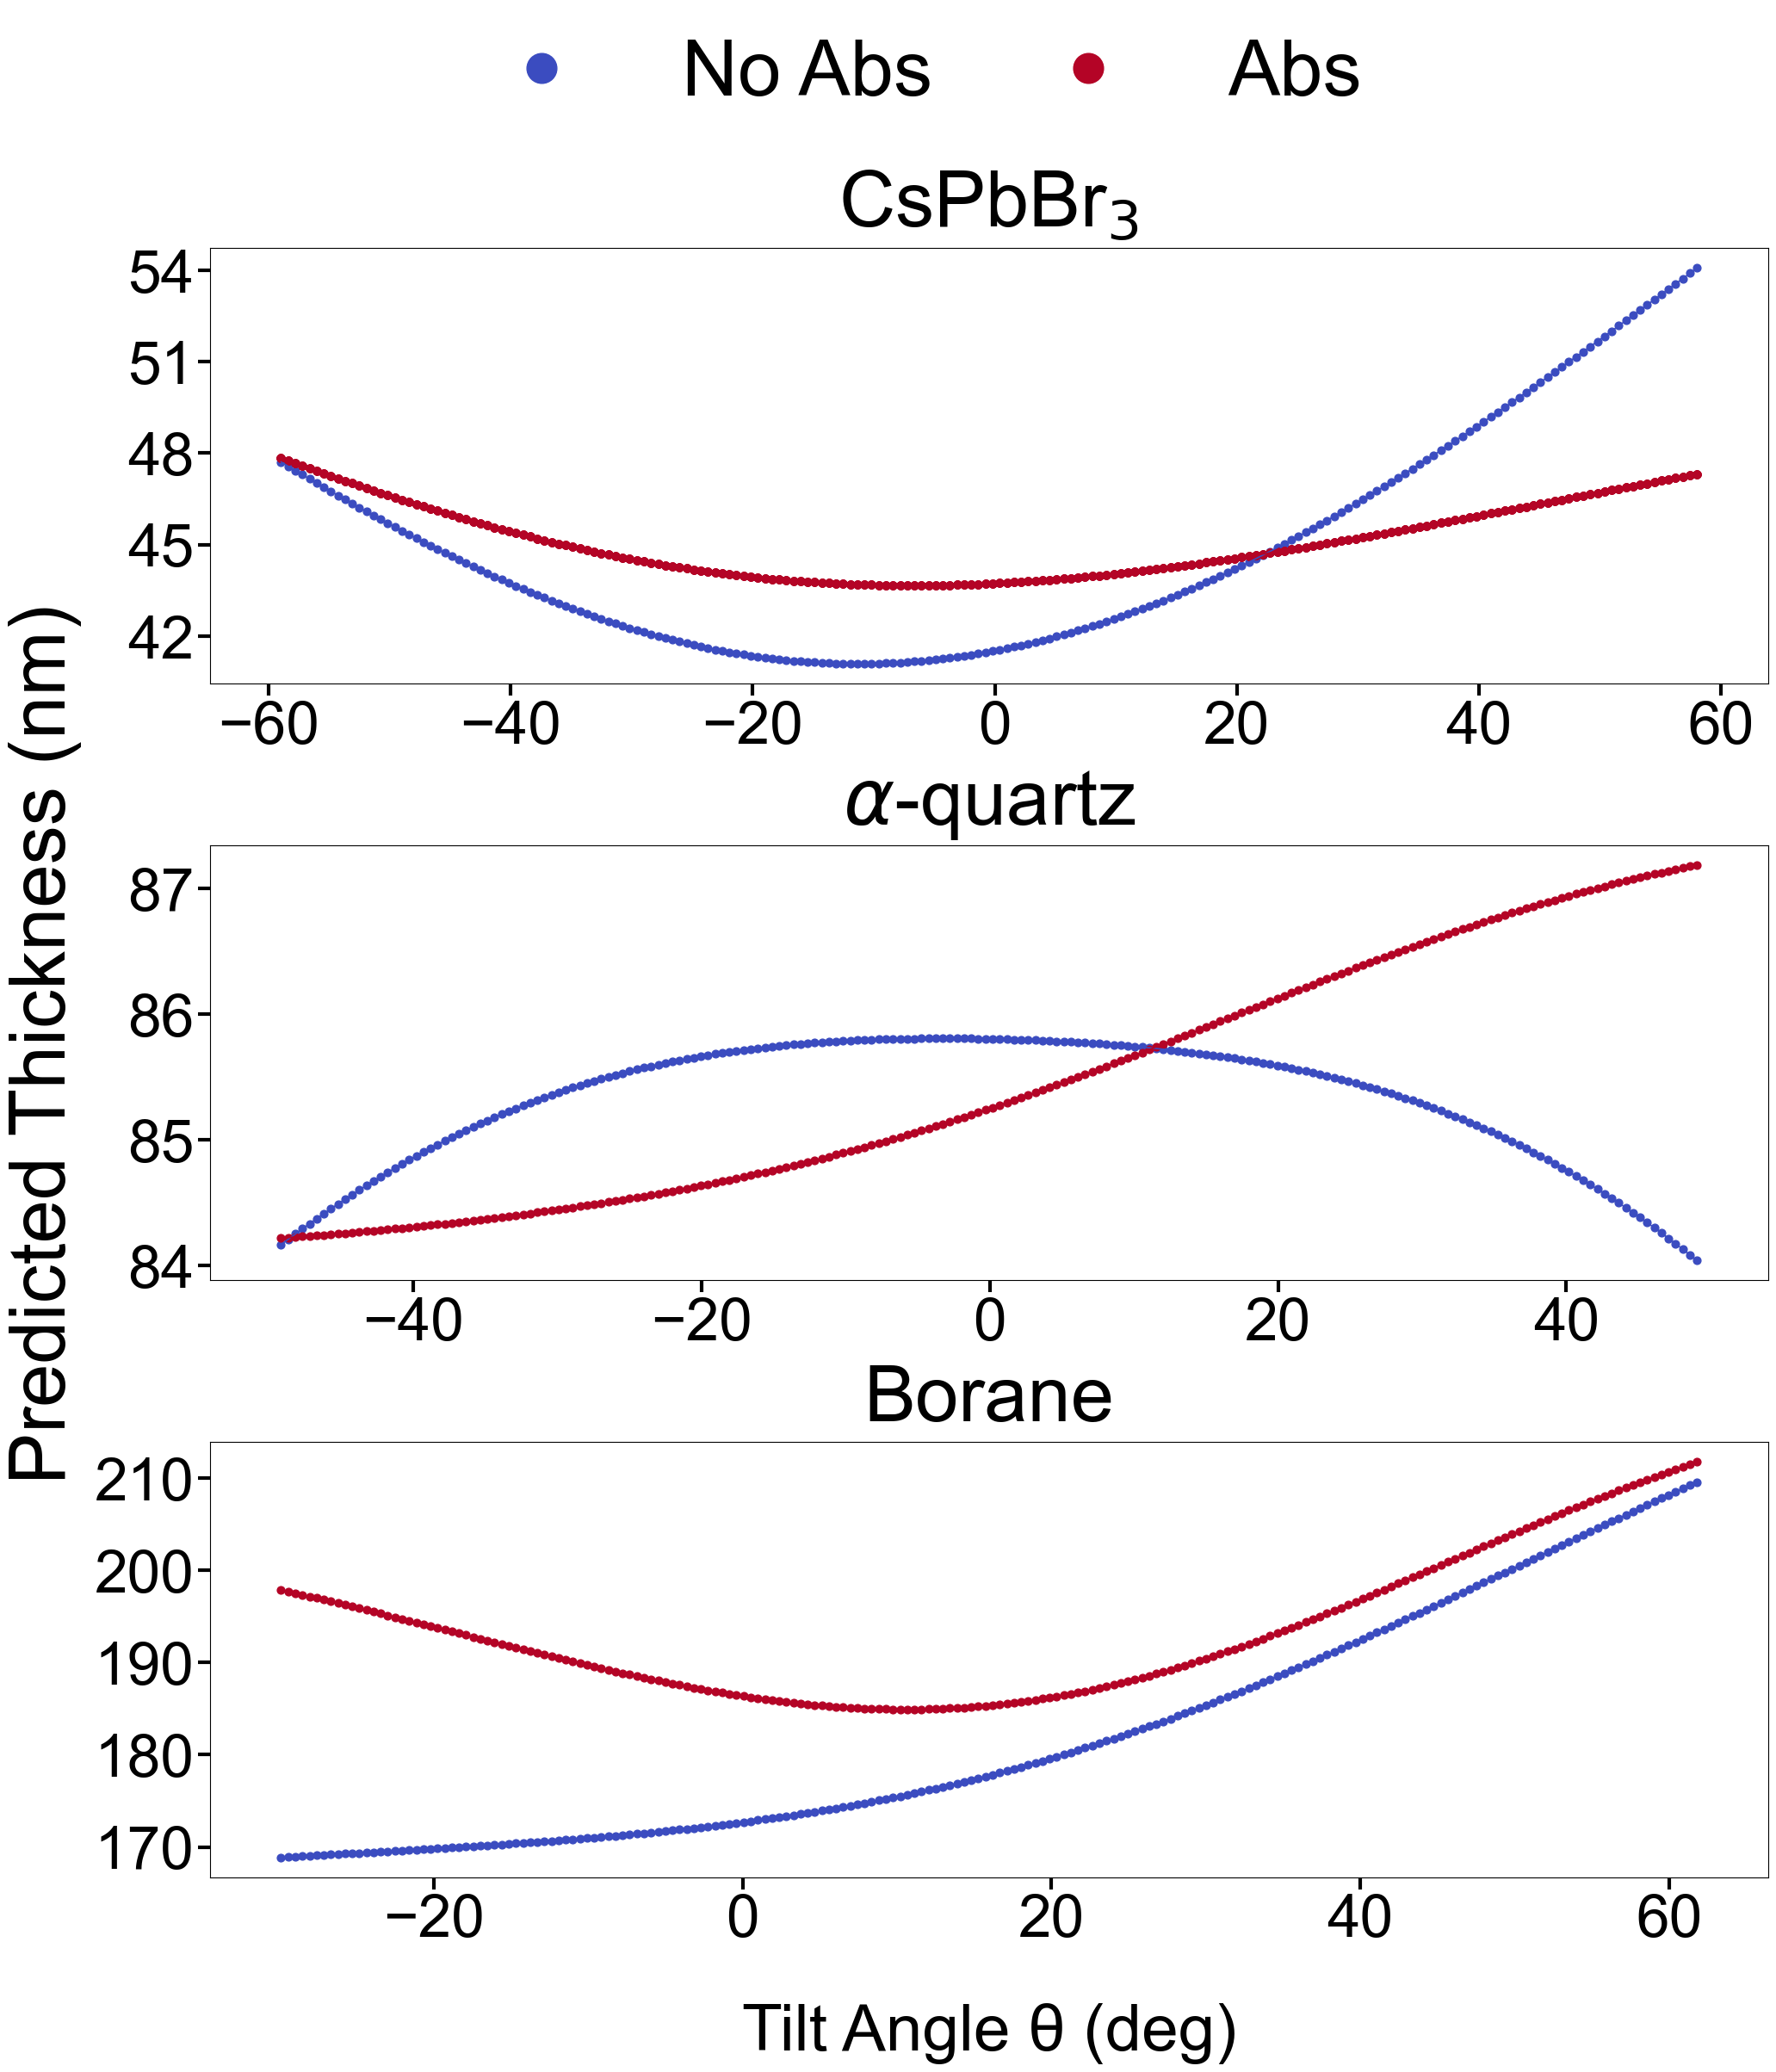

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# =========================================================
# FORCE ARIAL GLOBALLY
# =========================================================
plt.rcParams["font.family"] = "Arial"

# =========================================================
# EVEN + EVENLY SPACED TICK FUNCTION
# =========================================================
def set_even_ticks(ax, nticks_preferred=5):
    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin

    # If the whole span is tiny (< ~3 nm), use **2 ticks only**
    if yrange < 3.0:
        ticks = np.linspace(ymin, ymax, 3)
        ax.set_yticks(ticks)
        ax.set_yticklabels([f"{t:.0f}" for t in ticks])
        return

    # Otherwise, normal behaviour:
    ymin2 = ymin - 0.05 * yrange
    ymax2 = ymax + 0.05 * yrange
    ax.set_ylim(ymin2, ymax2)

    raw_step = (ymax2 - ymin2) / (nticks_preferred - 1)

    mag = 10 ** np.floor(np.log10(raw_step))
    step = round(raw_step / mag) * mag

    ticks = np.arange(ymin2, ymax2 + step * 0.5, step)

    if len(ticks) > nticks_preferred:
        ticks = np.linspace(ymin2, ymax2, nticks_preferred)

    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{int(round(t))}" for t in ticks])


# =========================================================
# FILE PATHS
# =========================================================
base = Path(str(REPO_ROOT / "absorption_paper_source_data/refinement_results"))

materials = [
    {
        "name": r"CsPbBr$_3$",
        "noabs": base / "cspbbr_no_abs/thickness.csv",
        "abs":   base / "cspbbr_abs/thickness.csv",
    },
    {
        "name": r"$\alpha$-quartz",
        "noabs": base / "quartz_no_abs/thickness.csv",
        "abs":   base / "quartz_abs/thickness.csv",
    },
    {
        "name": r"Borane",
        "noabs": base / "borane_no_abs/thickness.csv",
        "abs":   base / "borane_abs/thickness.csv",
    },
]

# =========================================================
# LOAD CSV
# =========================================================
def load_thickness_csv(path):
    df = pd.read_csv(path)
    theta = df["Theta"].values.astype(float)
    tvals_nm = df["Pred Thickness"].values.astype(float) * 0.1
    idx = np.argsort(theta)
    return theta[idx], tvals_nm[idx]

# =========================================================
# FIGURE
# =========================================================
fig, axes = plt.subplots(
    3, 1,
    figsize=(21, 24),
    sharex=False
)

blue = "#3b4cc0"
red  = "#b40426"

BIG = 55
MED = 50

# =========================================================
# LOOP MATERIALS
# =========================================================
for ax, mat in zip(axes, materials):

    theta_no, t_no = load_thickness_csv(mat["noabs"])
    theta_abs, t_abs = load_thickness_csv(mat["abs"])

    ax.scatter(theta_no, t_no, color=blue, s=40)
    ax.scatter(theta_abs, t_abs, color=red,  s=40)

    ax.plot(theta_no, t_no, color=blue, linewidth=1.2)
    ax.plot(theta_abs, t_abs, color=red,  linewidth=1.2)

    ax.set_title(mat["name"], fontsize=BIG+10, pad=18)

    # EVEN + EVEN-SPACED Y TICKS
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5, integer=True))


    ax.tick_params(axis="both", labelsize=MED, length=10, width=3)
    ax.grid(False)

# =========================================================
# SHARED LABELS
# =========================================================
fig.text(
    0.04, 0.5,
    "Predicted Thickness (nm)",
    ha="center", va="center",
    rotation="vertical",
    fontsize=BIG + 10
)

axes[-1].set_xlabel("Tilt Angle θ (deg)", fontsize=BIG, labelpad=45)

# =========================================================
# GLOBAL LEGEND
# =========================================================
legend_handles = [
    plt.Line2D([0], [0], marker="o", color=blue, markersize=25, linestyle=""),
    plt.Line2D([0], [0], marker="o", color=red,  markersize=25, linestyle="")
]

fig.legend(
    legend_handles,
    ["No Abs", "Abs"],
    loc="upper center",
    ncol=2,
    fontsize=BIG+10,
    frameon=False,
    bbox_to_anchor=(0.52, 1.02),
    columnspacing=1.0,
    handletextpad=0.8
)

plt.tight_layout(rect=[0.06, 0, 1, 0.93])
plt.show()


In [21]:
from CifFile import ReadCif
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# INPUT: two refinement-summary CIF files
# ---------------------------------------------------------
base = Path(str(REPO_ROOT / "absorption_paper_source_data/refinement_results"))

cif_noabs = base / "cspbbr_no_abs_refinement_summary.cif"
cif_abs   = base / "cspbbr_abs_refinement_summary.cif"

# ---------------------------------------------------------
# CIF → pandas table extractor
# ---------------------------------------------------------
def extract_asu_adp(cif_path):
    cf = ReadCif(str(cif_path))
    blk = cf[list(cf.keys())[0]]

    df = pd.DataFrame({
        "atom_id":  blk["_atom_site_asu_atom_id"],
        "element":  blk["_atom_site_asu_type"],
        "x":        blk["_atom_site_asu_fract_x"],
        "y":        blk["_atom_site_asu_fract_y"],
        "z":        blk["_atom_site_asu_fract_z"],
        "U11":      blk["_atom_site_aniso_u11"],
        "U22":      blk["_atom_site_aniso_u22"],
        "U33":      blk["_atom_site_aniso_u33"],
    })

    # convert numeric fields
    for col in ["x","y","z","U11","U22","U33"]:
        df[col] = df[col].astype(float)

    return df

# ---------------------------------------------------------
# LOAD BOTH TABLES
# ---------------------------------------------------------
df_noabs = extract_asu_adp(cif_noabs)
df_abs   = extract_asu_adp(cif_abs)

# sort atoms by atom_id
df_noabs = df_noabs.sort_values("atom_id").reset_index(drop=True)
df_abs   = df_abs.sort_values("atom_id").reset_index(drop=True)

# ---------------------------------------------------------
# BUILD LATEX TABLE
# ---------------------------------------------------------
latex_lines = []

latex_lines.append(r"\begin{table}[h!]")
latex_lines.append(r"\centering")
latex_lines.append(r"\small")
latex_lines.append(r"\caption{Fractional atomic coordinates and anisotropic displacement parameters from dynamical refinements of Borane performed with and without inclusion of absorption.}")
latex_lines.append(r"\label{tab:cspbbr3_refinement_comparison}")
latex_lines.append(r"\renewcommand{\arraystretch}{1.2}")
latex_lines.append(r"\setlength{\tabcolsep}{4pt}")

latex_lines.append(
    r"\begin{tabular}{lccc@{\hskip 1em}ccc@{\hskip 2em}ccc@{\hskip 1em}ccc}"
)
latex_lines.append(r"\hline")
latex_lines.append(
    r" & \multicolumn{6}{c}{\textbf{Without Absorption}} & "
    r"\multicolumn{6}{c}{\textbf{With Absorption}} \\"
)
latex_lines.append(
    r"Atom & $x$ & $y$ & $z$ & $U_{11}$ & $U_{22}$ & $U_{33}$ "
    r"& $x$ & $y$ & $z$ & $U_{11}$ & $U_{22}$ & $U_{33}$ \\"
)
latex_lines.append(r"\hline")

# ---------------------------------------------------------
# TABLE BODY
# ---------------------------------------------------------
for i in range(len(df_noabs)):
    rowA = df_noabs.iloc[i]
    rowB = df_abs.iloc[i]

    latex_lines.append(
        f"{rowA['element']}  & "
        f"{rowA['x']:.3f} & {rowA['y']:.3f} & {rowA['z']:.3f} & "
        f"{rowA['U11']:.3f} & {rowA['U22']:.3f} & {rowA['U33']:.3f} & "
        f"{rowB['x']:.3f} & {rowB['y']:.3f} & {rowB['z']:.3f} & "
        f"{rowB['U11']:.3f} & {rowB['U22']:.3f} & {rowB['U33']:.3f} \\\\"
    )

latex_lines.append(r"\hline")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\vspace{3pt}")
latex_lines.append(r"\smallskip")
latex_lines.append(r"\end{table}")

# ---------------------------------------------------------
# OUTPUT LATEX
# ---------------------------------------------------------
latex_table = "\n".join(latex_lines)
print(latex_table)



\begin{table}[h!]
\centering
\small
\caption{Fractional atomic coordinates and anisotropic displacement parameters from dynamical refinements of Borane performed with and without inclusion of absorption.}
\label{tab:cspbbr3_refinement_comparison}
\renewcommand{\arraystretch}{1.2}
\setlength{\tabcolsep}{4pt}
\begin{tabular}{lccc@{\hskip 1em}ccc@{\hskip 2em}ccc@{\hskip 1em}ccc}
\hline
 & \multicolumn{6}{c}{\textbf{Without Absorption}} & \multicolumn{6}{c}{\textbf{With Absorption}} \\
Atom & $x$ & $y$ & $z$ & $U_{11}$ & $U_{22}$ & $U_{33}$ & $x$ & $y$ & $z$ & $U_{11}$ & $U_{22}$ & $U_{33}$ \\
\hline
55  & 4.175 & 4.623 & 8.819 & 0.045 & 0.039 & 0.028 & 4.182 & 4.626 & 8.819 & 0.044 & 0.042 & 0.030 \\
82  & 4.059 & 8.359 & 5.880 & 0.016 & 0.014 & 0.014 & 4.059 & 8.359 & 5.880 & 0.016 & 0.014 & 0.014 \\
35  & 2.445 & 5.860 & 5.506 & 0.023 & 0.023 & 0.035 & 2.448 & 5.862 & 5.504 & 0.023 & 0.022 & 0.036 \\
35  & 3.564 & 8.314 & 8.819 & 0.043 & 0.044 & 0.012 & 3.562 & 8.307 & 8.819 & 0.048 & 0

In [22]:
from CifFile import ReadCif
import pandas as pd
from pathlib import Path
import string

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------
base = Path(str(REPO_ROOT / "absorption_paper_source_data/refinement_results"))

cif_noabs = base / "cspbbr_no_abs_refinement_summary.cif"
cif_abs   = base / "cspbbr_abs_refinement_summary.cif"

cell_cif  = Path(str(REPO_ROOT / "diffBloch_version_0.0.1/data/cspbbr3/cspbbr3.cif"))

# ---------------------------------------------------------
# LOAD UNIT CELL (AUTHORITATIVE SOURCE)
# ---------------------------------------------------------
cf_cell = ReadCif(str(cell_cif))
blk_cell = cf_cell[list(cf_cell.keys())[0]]

a = float(str(blk_cell["_cell_length_a"]).split("(")[0])
b = float(str(blk_cell["_cell_length_b"]).split("(")[0])
c = float(str(blk_cell["_cell_length_c"]).split("(")[0])

print(f"Using unit cell: a={a:.5f}, b={b:.5f}, c={c:.5f}")

# ---------------------------------------------------------
# CIF → pandas (CARTESIAN INPUT)
# ---------------------------------------------------------
def extract_asu_adp_cartesian(cif_path):
    cf = ReadCif(str(cif_path))
    blk = cf[list(cf.keys())[0]]

    df = pd.DataFrame({
        "atom_id": blk["_atom_site_asu_atom_id"],
        "element": blk["_atom_site_asu_type"],
        "x": blk["_atom_site_asu_fract_x"],
        "y": blk["_atom_site_asu_fract_y"],
        "z": blk["_atom_site_asu_fract_z"],
        "U11": blk["_atom_site_aniso_u11"],
        "U22": blk["_atom_site_aniso_u22"],
        "U33": blk["_atom_site_aniso_u33"],
    })

    for col in ["x","y","z","U11","U22","U33"]:
        df[col] = df[col].astype(float)

    return df

df_noabs = extract_asu_adp_cartesian(cif_noabs)
df_abs   = extract_asu_adp_cartesian(cif_abs)

# ---------------------------------------------------------
# CONVERT CARTESIAN → FRACTIONAL
# ---------------------------------------------------------
def cart_to_frac(df, a, b, c):
    df = df.copy()
    df["x_frac"] = df["x"] / a
    df["y_frac"] = df["y"] / b
    df["z_frac"] = df["z"] / c
    return df

df_noabs = cart_to_frac(df_noabs, a, b, c)
df_abs   = cart_to_frac(df_abs,   a, b, c)

# ---------------------------------------------------------
# RELABEL DUPLICATE ATOMS:  B → B1a, B1b, H → H1a, H1b, ...
# ---------------------------------------------------------
def relabel_atoms(df):
    df = df.copy()
    labels = []
    counters = {}

    for el in df["element"]:
        if el not in counters:
            counters[el] = 0
        counters[el] += 1
        suffix = string.ascii_lowercase[counters[el]-1]
        labels.append(f"{el}{suffix}")

    df["label"] = labels
    return df

df_noabs = relabel_atoms(df_noabs)
df_abs   = relabel_atoms(df_abs)

# ---------------------------------------------------------
# SORT FOR TABLE STABILITY
# ---------------------------------------------------------
df_noabs = df_noabs.sort_values("label").reset_index(drop=True)
df_abs   = df_abs.sort_values("label").reset_index(drop=True)

# ---------------------------------------------------------
# BUILD LaTeX TABLE
# ---------------------------------------------------------
latex = []
latex.append(r"\begin{table}[h!]")
latex.append(r"\centering")
latex.append(r"\small")
latex.append(r"\caption{Fractional atomic coordinates and anisotropic displacement parameters from dynamical refinements of borane with and without absorption.}")
latex.append(r"\renewcommand{\arraystretch}{1.2}")
latex.append(r"\setlength{\tabcolsep}{4pt}")
latex.append(r"\begin{tabular}{lccc ccc ccc ccc}")
latex.append(r"\hline")
latex.append(
    r"Atom & \multicolumn{6}{c}{No absorption} & \multicolumn{6}{c}{With absorption} \\"
)
latex.append(
    r"& $x$ & $y$ & $z$ & $U_{11}$ & $U_{22}$ & $U_{33}$ "
    r"& $x$ & $y$ & $z$ & $U_{11}$ & $U_{22}$ & $U_{33}$ \\"
)
latex.append(r"\hline")

for i in range(len(df_noabs)):
    A = df_noabs.iloc[i]
    B = df_abs.iloc[i]

    latex.append(
        f"{A['label']} & "
        f"{A['x_frac']:.4f} & {A['y_frac']:.4f} & {A['z_frac']:.4f} & "
        f"{A['U11']:.4f} & {A['U22']:.4f} & {A['U33']:.4f} & "
        f"{B['x_frac']:.4f} & {B['y_frac']:.4f} & {B['z_frac']:.4f} & "
        f"{B['U11']:.4f} & {B['U22']:.4f} & {B['U33']:.4f} \\\\"
    )

latex.append(r"\hline")
latex.append(r"\end{tabular}")
latex.append(r"\end{table}")

print("\n".join(latex))


Using unit cell: a=8.11890, b=8.35900, c=11.75900
\begin{table}[h!]
\centering
\small
\caption{Fractional atomic coordinates and anisotropic displacement parameters from dynamical refinements of borane with and without absorption.}
\renewcommand{\arraystretch}{1.2}
\setlength{\tabcolsep}{4pt}
\begin{tabular}{lccc ccc ccc ccc}
\hline
Atom & \multicolumn{6}{c}{No absorption} & \multicolumn{6}{c}{With absorption} \\
& $x$ & $y$ & $z$ & $U_{11}$ & $U_{22}$ & $U_{33}$ & $x$ & $y$ & $z$ & $U_{11}$ & $U_{22}$ & $U_{33}$ \\
\hline
35a & 0.3012 & 0.7011 & 0.4682 & 0.0227 & 0.0230 & 0.0350 & 0.3015 & 0.7013 & 0.4681 & 0.0228 & 0.0222 & 0.0358 \\
35b & 0.4390 & 0.9946 & 0.7500 & 0.0428 & 0.0435 & 0.0119 & 0.4387 & 0.9937 & 0.7500 & 0.0482 & 0.0462 & 0.0112 \\
55a & 0.5142 & 0.5531 & 0.7500 & 0.0448 & 0.0388 & 0.0282 & 0.5151 & 0.5535 & 0.7500 & 0.0439 & 0.0416 & 0.0296 \\
82a & 0.5000 & 1.0000 & 0.5000 & 0.0163 & 0.0142 & 0.0145 & 0.5000 & 1.0000 & 0.5000 & 0.0159 & 0.0137 & 0.0140 \\
\hline
\end

Mean R_obs no abs: 6.344082610586939
Mean R_obs abs:    5.2717584485219655
Mean wR no abs:    6.694151647388931
Mean wR abs:       5.419504162618664


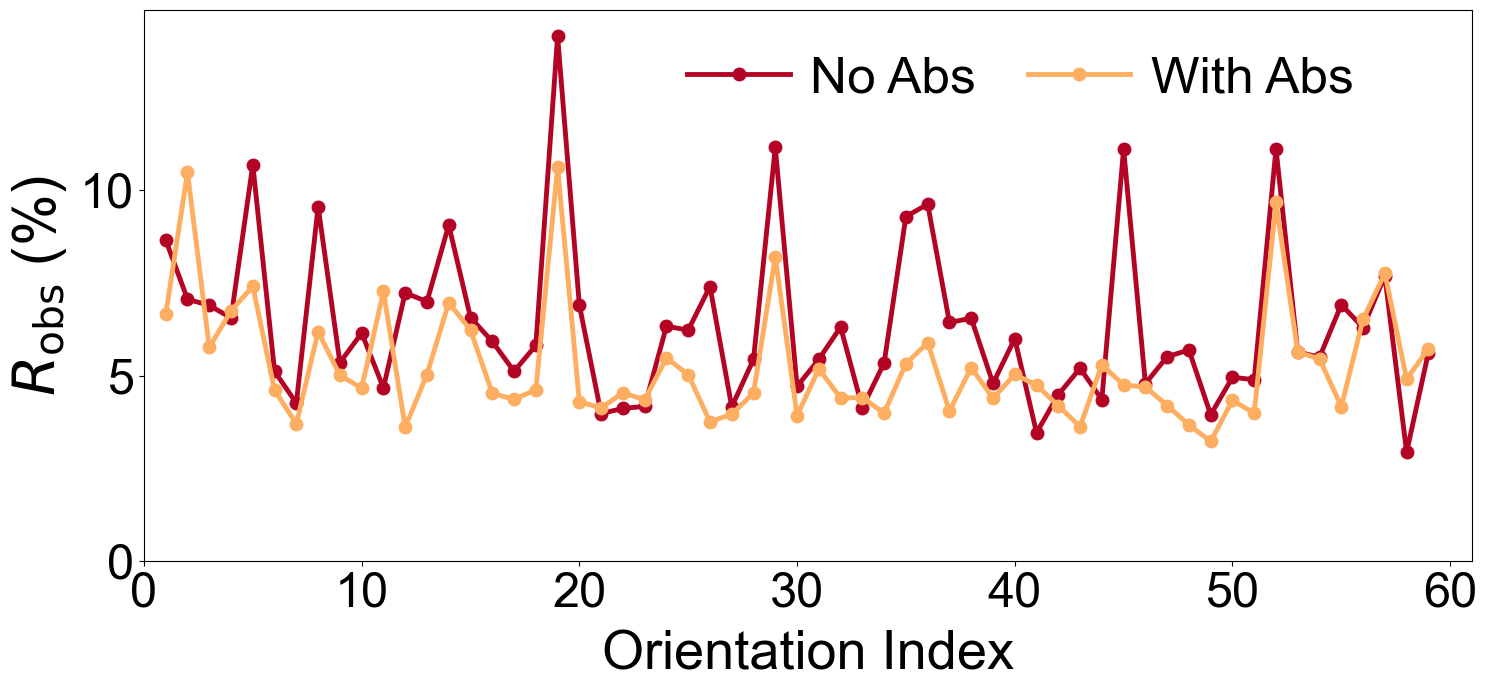

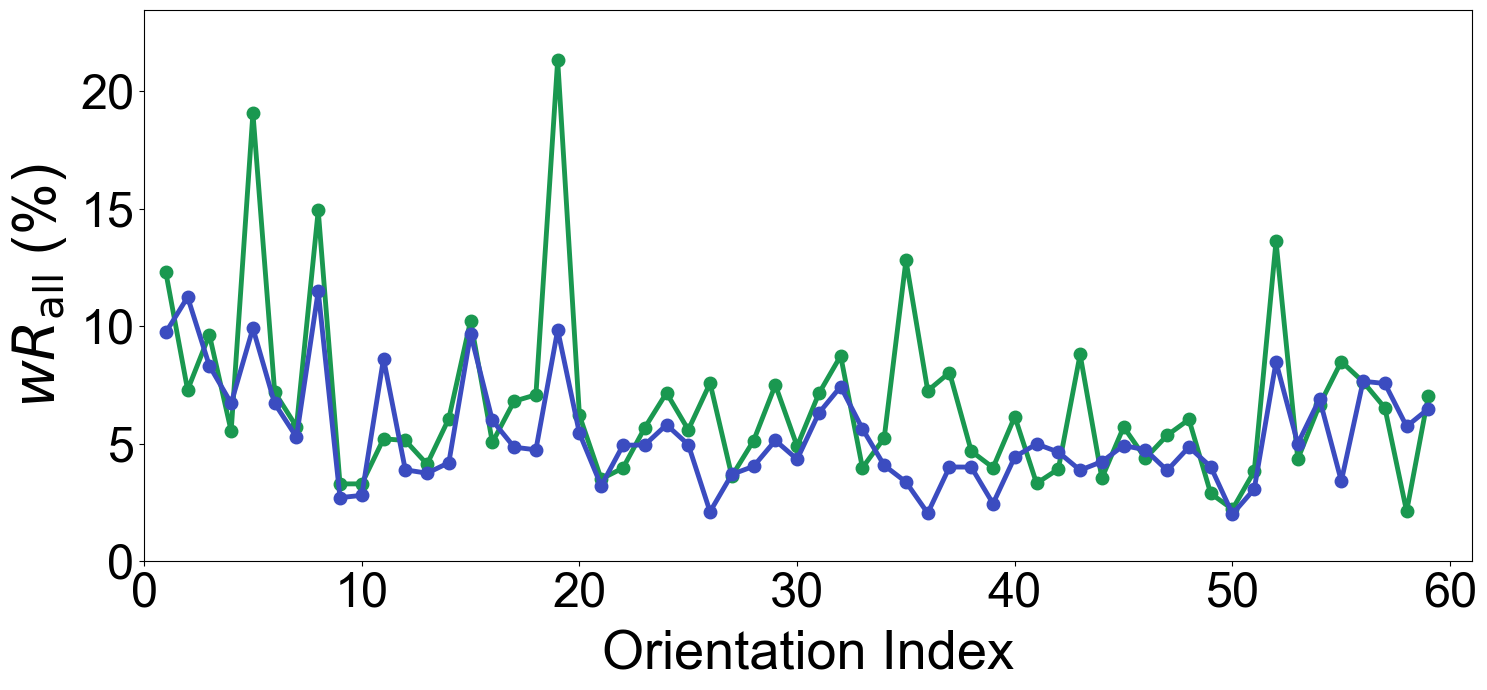

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from CifFile import ReadCif
from pathlib import Path

# =========================================================
# FORCE ARIAL FONT GLOBALLY
# =========================================================
plt.rcParams["font.family"] = "Arial"

# =========================================================
# FILE PATHS
# =========================================================
base = Path(str(REPO_ROOT / "absorption_paper_source_data/refinement_results"))

cif_noabs = base / "cspbbr_no_abs_refinement_summary.cif"
cif_abs   = base / "cspbbr_abs_refinement_summary.cif"

# =========================================================
# CIF LOADER
# =========================================================
def load_refinement_cif(path):
    cf = ReadCif(str(path))
    block = cf[list(cf.keys())[0]]

    rot  = np.array(block["_refine_rot_index"], dtype=int)
    r    = np.array(block["_refine_ls_R_bragg"], dtype=float) * 100
    wr   = np.array(block["_refine_ls_wR_all"], dtype=float) * 100

    return {"rot": rot, "Robs": r, "wR": wr}

# =========================================================
# LOAD + SORT DATA
# =========================================================
noabs = load_refinement_cif(cif_noabs)
abs_  = load_refinement_cif(cif_abs)

idx_noabs = np.argsort(noabs["rot"])
idx_abs   = np.argsort(abs_["rot"])

x_noabs = noabs["rot"][idx_noabs] + 1
x_abs   = abs_["rot"][idx_abs] + 1

y_Robs_noabs = noabs["Robs"][idx_noabs]
y_Robs_abs   = abs_["Robs"][idx_abs]

y_wR_noabs = noabs["wR"][idx_noabs]
y_wR_abs   = abs_["wR"][idx_abs]

# =========================================================
# MEANS + LEGEND TOGGLE
# =========================================================
include_mean = False

mean_R_noabs = y_Robs_noabs.mean()
mean_R_abs   = y_Robs_abs.mean()

mean_wR_noabs = y_wR_noabs.mean()
mean_wR_abs   = y_wR_abs.mean()

print("Mean R_obs no abs:", mean_R_noabs)
print("Mean R_obs abs:   ", mean_R_abs)
print("Mean wR no abs:   ", mean_wR_noabs)
print("Mean wR abs:      ", mean_wR_abs)

def label(base, mean):
    return f"{base} (mean={mean:.2f}%)" if include_mean else base

# =========================================================
# COLORS
# =========================================================
blue   = "#3b4cc0"
green  = "#1a9850"
red    = "#b40426"
orange = "#fdae61"

# =========================================================
# 1) PLOT R(obs)
# =========================================================
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(x_noabs, y_Robs_noabs, "-o", color=red, linewidth=3.5, markersize=9,
        label=label("No Abs", mean_R_noabs))

ax.plot(x_abs, y_Robs_abs, "-o", color=orange, linewidth=3.5, markersize=9,
        label=label("With Abs", mean_R_abs))

ax.set_xlabel("Orientation Index", fontsize=39, labelpad=10)
ax.set_ylabel(r"$R_\mathrm{obs}$ (%)", fontsize=42, labelpad=8)
ax.tick_params(axis="x", labelsize=35)
ax.tick_params(axis="y", labelsize=35)
ax.set_xlim(x_noabs.min() - 1, x_noabs.max() + 2)
ax.set_ylim(0, max(y_Robs_noabs.max(), y_Robs_abs.max()) * 1.05)
ax.legend(
    frameon=False,
    fontsize=37,
    loc="upper center",
    bbox_to_anchor=(0.66, 1),
    ncol=2,
    columnspacing=1.0,
    handletextpad=0.4
)


plt.tight_layout()
plt.show()

# =========================================================
# 2) PLOT wR(all)
# =========================================================
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(x_noabs, y_wR_noabs, "-o", color=green, linewidth=3.5, markersize=9,
        label=label("No Absorption", mean_wR_noabs))

ax.plot(x_abs, y_wR_abs, "-o", color=blue, linewidth=3.5, markersize=9,
        label=label("With Absorption", mean_wR_abs))

ax.set_xlabel("Orientation Index", fontsize=39, labelpad=10)
ax.set_ylabel(r"$wR_\mathrm{all}$ (%)", fontsize=42, labelpad=8)
ax.tick_params(axis="x", labelsize=35)
ax.tick_params(axis="y", labelsize=35)
ax.set_xlim(x_noabs.min() - 1, x_noabs.max() + 2)
ax.set_ylim(0, max(y_wR_noabs.max(), y_wR_abs.max()) * 1.1)


plt.tight_layout()
plt.show()


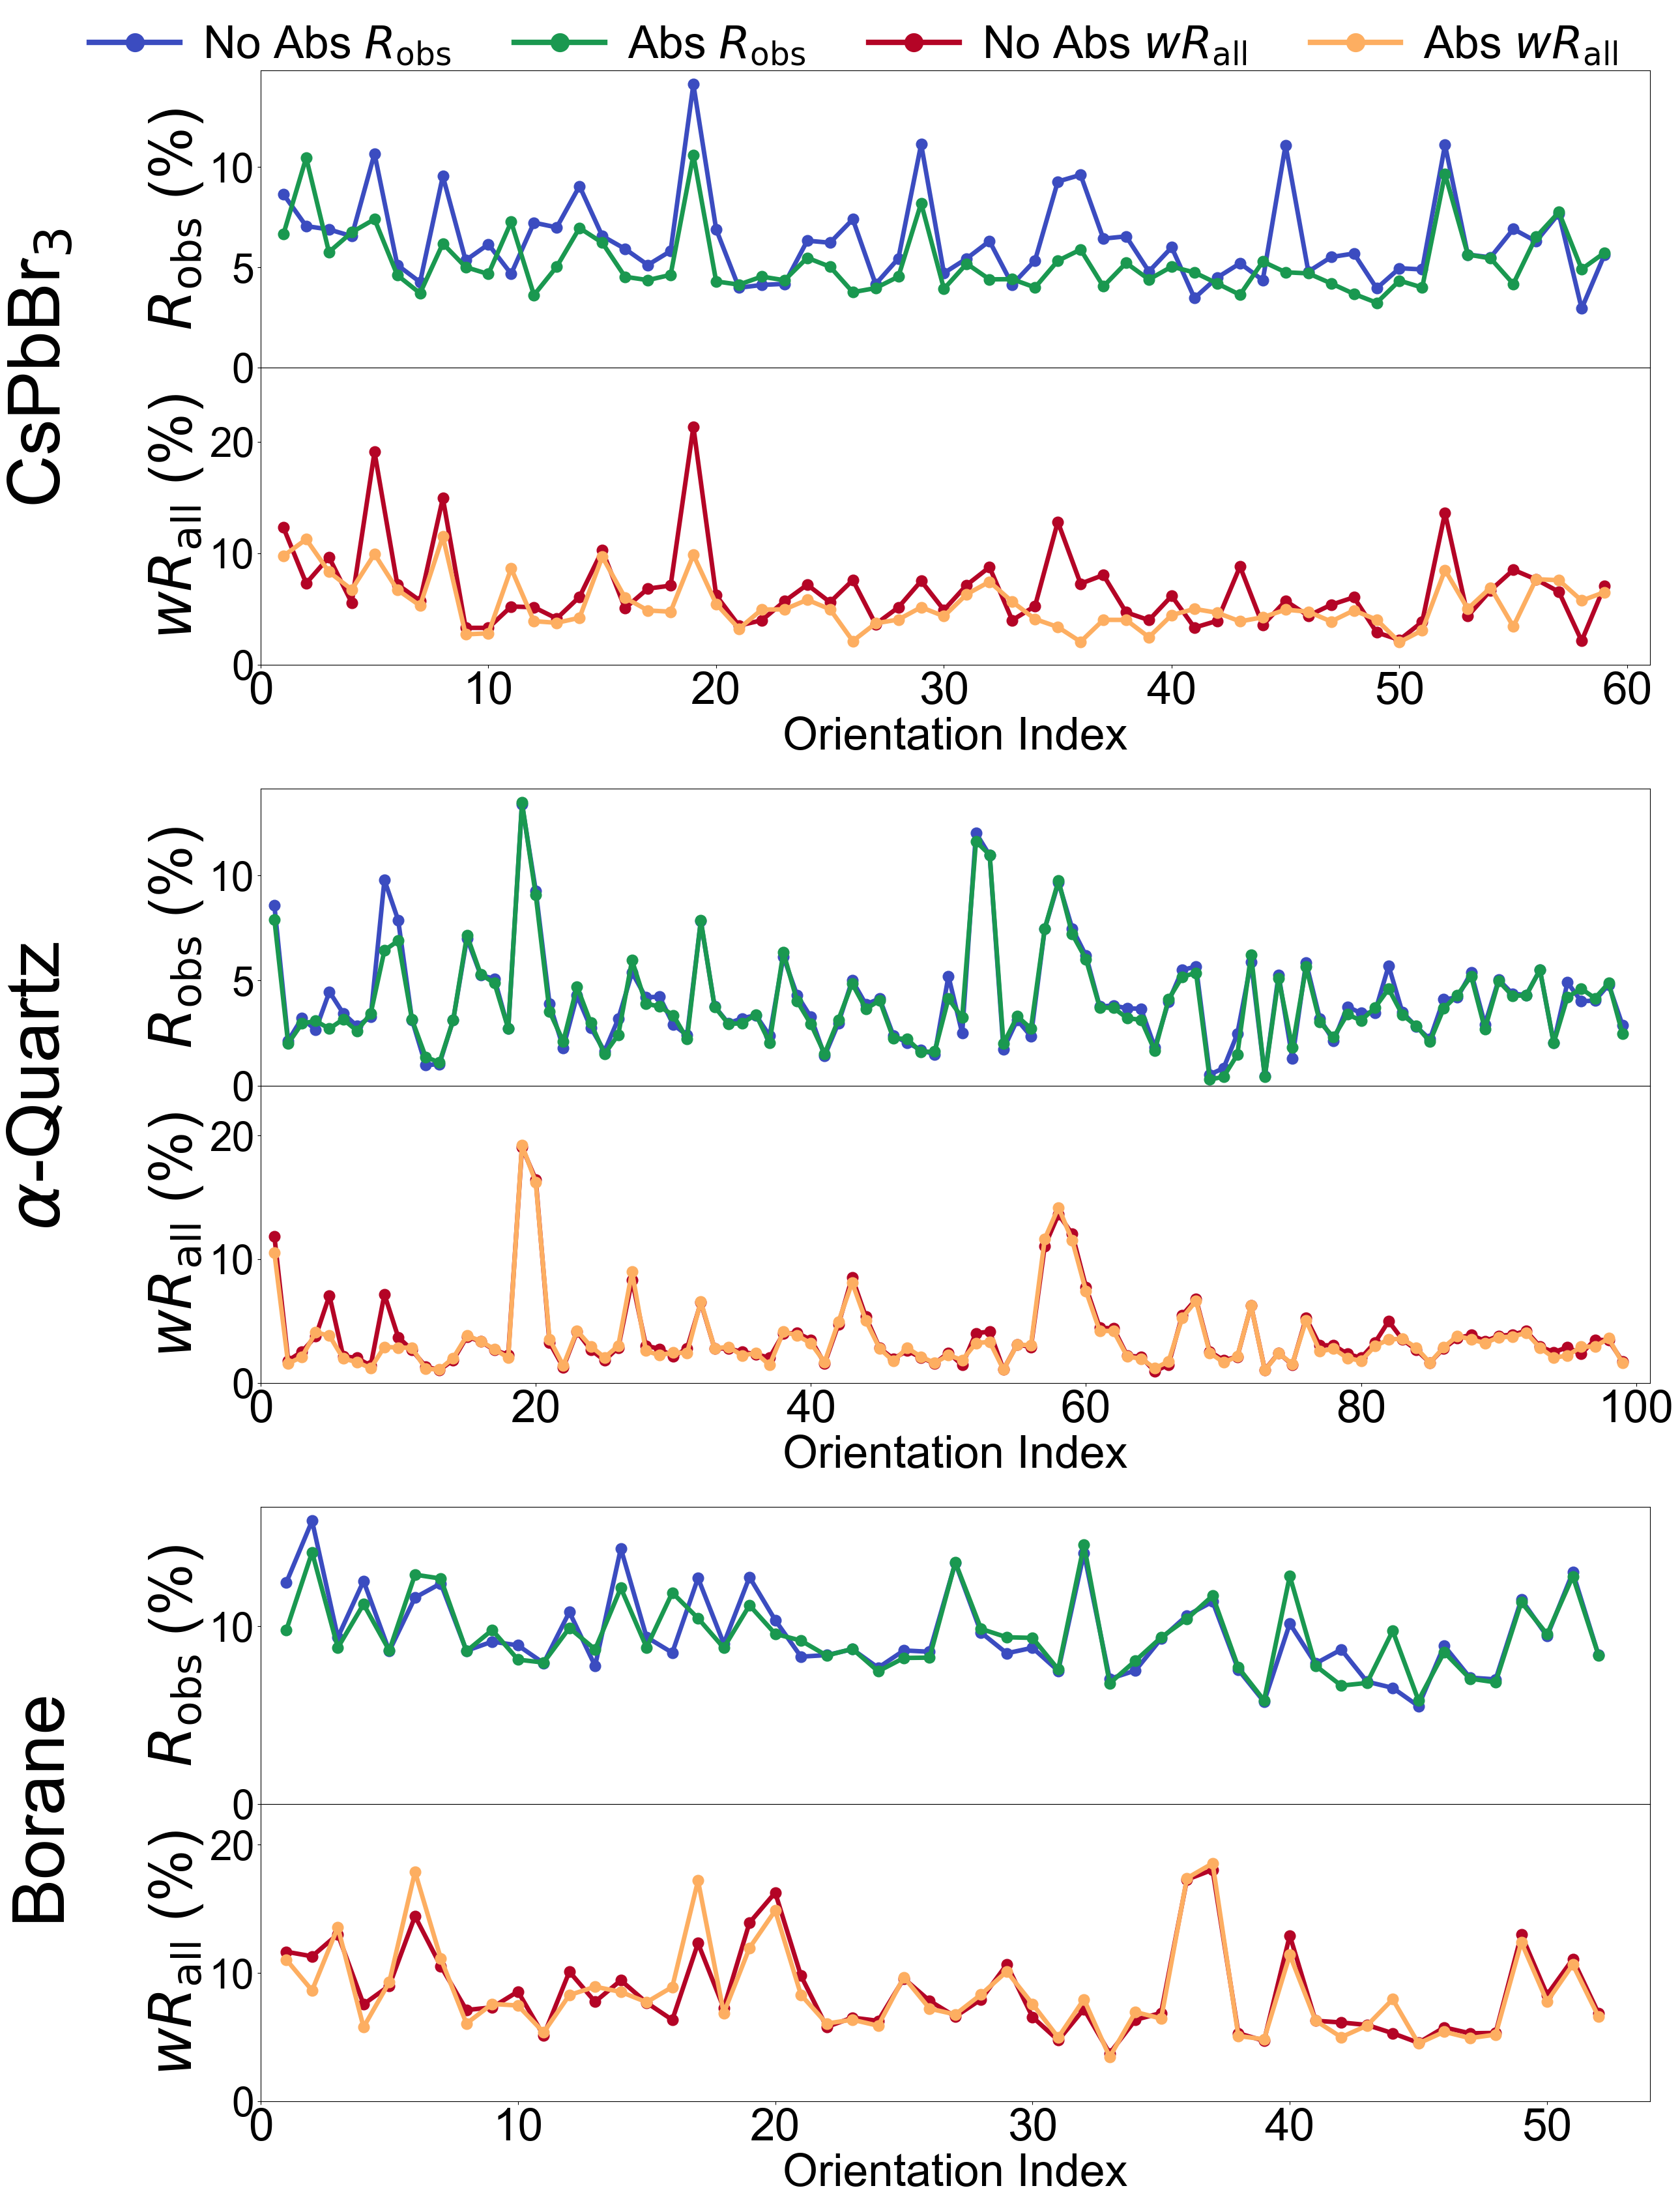

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from CifFile import ReadCif
from pathlib import Path

# =========================================================
# FORCE ARIAL FONT GLOBALLY
# =========================================================
plt.rcParams["font.family"] = "Arial"

# =========================================================
# FILE PATHS + MATERIALS
# =========================================================
base = Path(str(REPO_ROOT / "absorption_paper_source_data/refinement_results"))

materials = [
    {
        "name": r"CsPbBr$_3$",
        "noabs": base / "cspbbr_no_abs_refinement_summary.cif",
        "abs":   base / "cspbbr_abs_refinement_summary.cif",
    },
    {
        "name": r"$\alpha$-Quartz",
        "noabs": base / "quartz_no_abs_refinement_summary.cif",
        "abs":   base / "quartz_abs_refinement_summary.cif",
    },
    {
        "name": r"Borane",
        "noabs": base / "borane_no_abs_refinement_summary.cif",
        "abs":   base / "borane_abs_refinement_summary.cif",
    },
]

# =========================================================
# CIF loader
# =========================================================
def load_refinement_cif(path):
    cf = ReadCif(str(path))
    block = cf[list(cf.keys())[0]]

    rot = np.array(block["_refine_rot_index"], dtype=int)
    R   = np.array(block["_refine_ls_R_bragg"], dtype=float) * 100
    wR  = np.array(block["_refine_ls_wR_all"], dtype=float) * 100

    idx = np.argsort(rot)

    return {
        "rot": rot[idx] + 1,
        "Robs": R[idx],
        "wR": wR[idx],
    }

# =========================================================
# COLORS + FONT SIZES
# =========================================================
blue   = "#3b4cc0"
green  = "#1a9850"
red    = "#b40426"
orange = "#fdae61"

label_fs = 50
tick_fs  = 50

# =========================================================
# FIGURE — 6 ROWS
# =========================================================
fig, axes = plt.subplots(
    6, 1,
    figsize=(26, 38),
    sharex=False
)

fig.subplots_adjust(hspace=0)

# =========================================================
# TOP LEGEND
# =========================================================
legend_elements = [
    Line2D([0], [0], color=blue,   marker='o', markersize=20, linewidth=6, label=r"No Abs $R_\mathrm{obs}$"),
    Line2D([0], [0], color=green,  marker='o', markersize=20, linewidth=6, label=r"Abs $R_\mathrm{obs}$"),
    Line2D([0], [0], color=red,    marker='o', markersize=20, linewidth=6, label=r"No Abs $wR_\mathrm{all}$"),
    Line2D([0], [0], color=orange, marker='o', markersize=20, linewidth=6, label=r"Abs $wR_\mathrm{all}$"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    fontsize=50,
    frameon=False,
    ncol=4,
    bbox_to_anchor=(0.5, 0.995),
    columnspacing=1.4,
    handletextpad=0.5,
)

# =========================================================
# MANUAL SUBPLOT POSITIONS
# =========================================================
small = 0.01
large = 0.22

positions = [
    (0.84, small),
    (0.84 - 0.12, small),

    (0.55, large),
    (0.55 - 0.12, small),

    (0.26, large),
    (0.26 - 0.12, small),
]

for ax, (y, gap) in zip(axes, positions):
    ax.set_position([0.15, y, 0.82, 0.12])

# =========================================================
# LOOP OVER MATERIALS
# =========================================================
panel = 0

for mat_idx, mat in enumerate(materials):

    dat_noabs = load_refinement_cif(mat["noabs"])
    dat_abs   = load_refinement_cif(mat["abs"])

    x_noabs = dat_noabs["rot"]
    x_abs   = dat_abs["rot"]

    yR_noabs = dat_noabs["Robs"]
    yR_abs   = dat_abs["Robs"]

    yw_noabs = dat_noabs["wR"]
    yw_abs   = dat_abs["wR"]

    top_ax = axes[panel]
    bot_ax = axes[panel+1]

    y_center = (top_ax.get_position().y0 + bot_ax.get_position().y1) / 2

    fig.text(
        0.02,
        y_center,
        mat["name"],
        va="center",
        ha="center",
        fontsize=80,
        rotation="vertical"
    )

    # R(obs)
    axR = top_ax
    axR.plot(x_noabs, yR_noabs, "-o", color=blue,  linewidth=5, markersize=12)
    axR.plot(x_abs,   yR_abs,   "-o", color=green, linewidth=5, markersize=12)

    axR.set_ylabel(r"$R_\mathrm{obs}$ (%)", fontsize=label_fs+15)
    axR.tick_params(axis="y", labelsize=tick_fs-5)
    axR.set_ylim(0, max(yR_noabs.max(), yR_abs.max()) * 1.05)
    axR.tick_params(axis="x", bottom=False, labelbottom=False)

    # wR(all)
    axw = bot_ax
    axw.plot(x_noabs, yw_noabs, "-o", color=red,    linewidth=5, markersize=12)
    axw.plot(x_abs,   yw_abs,   "-o", color=orange, linewidth=5, markersize=12)

    axw.set_ylabel(r"$wR_\mathrm{all}$ (%)", fontsize=label_fs+15)
    axw.tick_params(axis="y", labelsize=tick_fs-5)
    axw.set_ylim(0, max(yw_noabs.max(), yw_abs.max()) * 1.25)
    axw.margins(y=0.08)


    axw.set_xlabel("Orientation Index", fontsize=label_fs)
    axw.tick_params(axis="x", labelsize=label_fs)

    xmin = min(x_noabs.min(), x_abs.min()) - 1
    xmax = max(x_noabs.max(), x_abs.max()) + 2
    axR.set_xlim(xmin, xmax)
    axw.set_xlim(xmin, xmax)

    panel += 2

plt.show()
